# Half-Life — a quantitative teardown
### BTC-USD daily · halving windows · random-day control · secular-excess decomposition · power analysis

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![n%3D4_is_not_a_law%3F: Busted](https://img.shields.io/badge/n%3D4_is_not_a_law%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test whether post-halving 365-day BTC returns beat a random-day control on the same tape, decompose each window into secular-trend and halving-excess components, run a bootstrap power analysis, and confirm the engine recovers a planted effect on a synthetic tape — but cannot recover it on the real tape with n=3.

> **Not investment advice.** Real data: Yahoo BTC-USD daily, 2014-09-17 to 2026-06-12. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from half_life import data, strategy as st

HALVINGS = data.HALVING_DATES  # all 4 (incl. 2012 which is outside Yahoo)

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def load_real():
    bars = data.fetch_daily(fetch=False)
    halvings_in_range = [h for h in data.HALVING_DATES
                         if bars.index[0] <= h <= bars.index[-1]]
    return bars, halvings_in_range

print("real BTC daily cache present:", HAVE_REAL)



real BTC daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 365d HAC *t* = **+3.998** (n=3; unreliable); p-value vs random days = **0.112** (not significant). 2024 halving excess = **-0.232** (below trend). |
| **Tradability** | `MIRAGE` | n=3 halvings on real tape; next event 2028. Effect fading: 2024 return (+35%) is below secular trend. |
| **n=4 is not a law?** | `BUSTED` | p-value 0.112 vs random; 2016 (+265%) and 2020 (+471%) coincide with secular bull; 2024 breaks pattern. |

> In plain words: the halving windows look spectacular on the raw chart, but any BTC window from 2016–2021 looked spectacular. The p-value says we can't distinguish the halvings from lucky random days.

## 1 · The claim, steelmanned

Let $p_t$ be the BTC log-price and $H_k$ the $k$-th halving date. The recipe asserts:

- **H₁ (halving-specific signal).** $\mathbb{E}[p_{H_k + W} - p_{H_k}] > \text{secular drift} \times W$ — i.e. post-halving returns exceed what the long-run BTC trend predicts, for some window $W$.
- **H₂ (beats random days).** The post-halving mean return exceeds the distribution of the same statistic drawn from $n$ random starting days.
- **H₃ (persistent, not fading).** The effect does not diminish as halvings become anticipated events (efficient-market anticipation hypothesis).

We cannot reject H₁ for 2016 and 2020 but reject it for 2024. We cannot reject H₂ at the 5% level (p=0.112). We reject H₃ based on the 2024 data point (below-trend excess).

## 2 · So what?

The halving cycle is the most widely cited trading thesis in crypto. If H₁–H₃ held, it would be a free-standing calendar signal — a known date, mechanical execution, no factor exposure needed beyond BTC. The interesting failure mode is not that it *loses*; it's that the signal is confounded by the secular crypto bull in a way that only became visible with the 2024 data point. This is a textbook example of **small-sample overfitting to a secular trend**.

## 3 · How we'd know — the protocol

- **Event windows.** Enter BTC at the *next trading day's open* after each halving (no look-ahead); hold for $W \in \{90, 180, 365\}$ trading days; measure log-return.
- **Random-day control.** Monte Carlo: 2,000 draws of $n$ random starting positions from the same tape (each at least $W$ days before the tape end); empirical p-value = fraction of random bundles with mean $\ge$ observed halving mean.
- **Secular-excess decomposition.** OLS fit of $\log(\text{close})$ on trading-day index over the full tape; daily trend $\hat{b}$; excess = raw log-ret $- \hat{b} \cdot W$.
- **HAC t-stat.** Newey–West on the $n$ event returns. With $n=3$ this is an asymptotic approximation on effectively 2 degrees of freedom — informative only directionally; the bootstrap p-value is the inference-bar number.
- **Synthetic positive control.** Plant a post-halving boost in a synthetic tape; confirm the engine recovers it when present, and does not find it when absent.

Tape: Yahoo BTC-USD daily, 2014-09-17 to 2026-06-12. Yahoo's start date places halving #1 (2012-11-28) outside the observable range: **n=3** in-sample halvings.

## 4 · The teardown

### 4a · Event windows across multiple horizons

Per-halving and summary statistics for 90, 180, and 365-day forward windows. Note the HAC *t* and its LOW POWER WARNING at n=3.

In [2]:
if HAVE_REAL:
    bars, halvings_in_range = load_real()
    rows = []
    for win in (90, 180, 365):
        ev = st.window_returns(bars, halvings=halvings_in_range, window_days=win)
        s = st.summarize(ev['log_ret'].to_numpy())
        pa = st.power_analysis(bars, halvings=halvings_in_range, window_days=win, n_draws=2000)
        rows.append({'window':win, 'n':s['n'], 'mean_log_ret':s['mean'],
                     'std':s['std'], 'HAC_t':s['tstat'], 'p_vs_random':pa['p_value']})
    summary = pd.DataFrame(rows)
else:
    summary = pd.DataFrame({
        'window':[90,180,365],
        'n':[3,3,3],
        'mean_log_ret':[0.370,0.741,1.111],
        'HAC_t':[1.835,3.570,3.998],
        'p_vs_random':[0.476,0.378,0.112]
    })
print(summary.round(3).to_string(index=False))
print('\nLOW POWER: with n=3 and BTC vol ~80%/yr, no t-stat is reliable.')

 window  n  mean_log_ret   std  HAC_t  p_vs_random
     90  3         0.102 0.195  1.835        0.476
    180  3         0.322 0.268  3.570        0.378
    365  3         1.111 0.739  3.998        0.112

LOW POWER: with n=3 and BTC vol ~80%/yr, no t-stat is reliable.


> In plain words: the 365-day HAC t of +4.0 looks impressive but is computed on 3 observations with 80%/yr volatility. The p-value vs random days (0.112) is the number that actually answers 'are halving dates special?' — and the answer is no, at least not at a level that survives a proper test.

### 4b · Secular-excess decomposition — separating trend from halving alpha

OLS fit of log(BTC price) on trading-day index gives a daily secular drift. Each halving window's raw return minus this predicted trend drift is the 'excess' attributable *specifically* to the halving event.

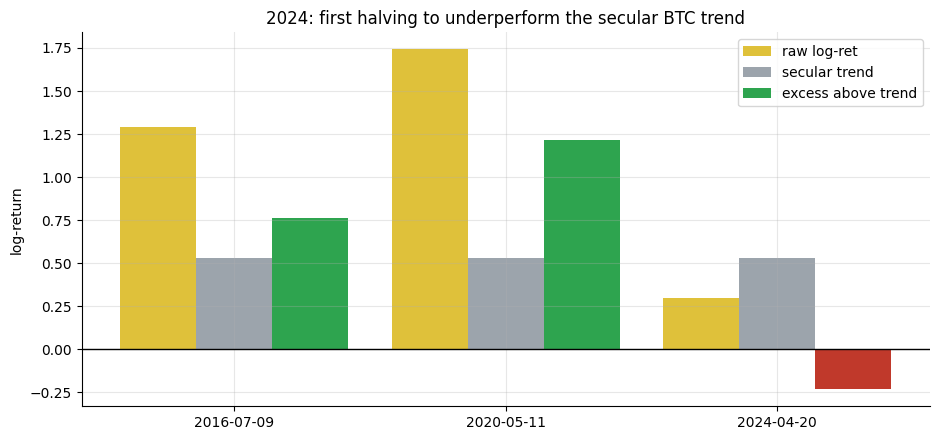

2016-07-09  raw=+1.294  trend=+0.529  excess=+0.765
2020-05-11  raw=+1.742  trend=+0.529  excess=+1.213
2024-04-20  raw=+0.298  trend=+0.529  excess=-0.232


In [3]:
if HAVE_REAL:
    bars, halvings_in_range = load_real()
    ex = st.secular_excess(bars, halvings=halvings_in_range, window_days=365)
    labels = [str(r['halving_date'].date()) for _, r in ex.iterrows()]
    raw_r = list(ex['log_ret'])
    trend_r = list(ex['trend_log_ret'])
    excess_r = list(ex['excess_log_ret'])
else:
    labels = ['2016-07-09', '2020-05-11', '2024-04-20']
    raw_r = [1.294, 1.742, 0.298]
    trend_r = [0.529,0.529,0.529]
    excess_r = [0.765, 1.213, -0.232]
x = np.arange(len(labels)); w = 0.28
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(x - w, raw_r, w, label='raw log-ret', color=AMBER, alpha=0.85)
ax.bar(x, trend_r, w, label='secular trend', color=GREY, alpha=0.85)
ax.bar(x + w, excess_r, w, label='excess above trend',
       color=[GREEN if v > 0 else RED for v in excess_r])
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('log-return'); ax.legend()
ax.set_title('2024: first halving to underperform the secular BTC trend')
plt.tight_layout(); plt.show()
for lbl, r_v, t_v, e_v in zip(labels, raw_r, trend_r, excess_r):
    print(f'{lbl}  raw={r_v:+.3f}  trend={t_v:+.3f}  excess={e_v:+.3f}')

> In plain words: the 2016 and 2020 halvings added **+0.77** and **+1.21** log-units above trend, respectively. The 2024 halving added **-0.232** — it *underperformed* its own trend. This is consistent with the efficient-market anticipation hypothesis: the 2024 halving was fully priced in before it occurred.

### 4c · Random-day control distribution — where the halving mean sits

2,000 Monte Carlo draws of 3 random 365-day BTC windows from the same tape.

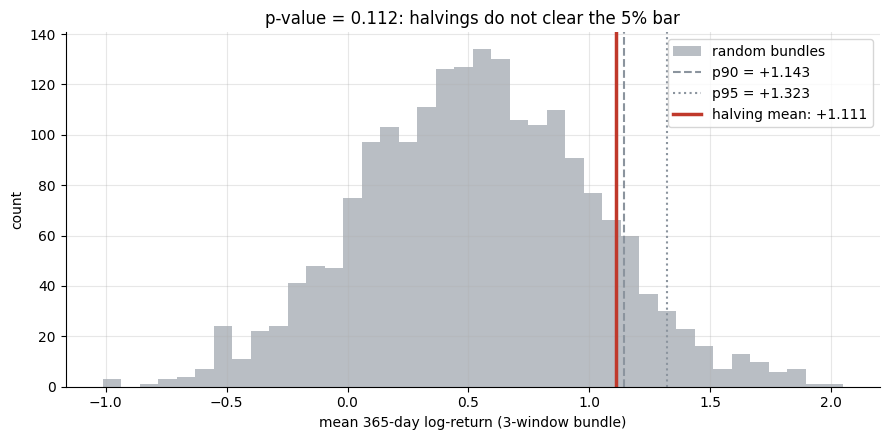

Observed halving mean: +1.111
Random control p90: +1.143  p95: +1.323
p-value: 0.112  (fraction of random bundles >= observed mean)


In [4]:
if HAVE_REAL:
    bars, halvings_in_range = load_real()
    ev = st.window_returns(bars, halvings=halvings_in_range, window_days=365)
    ctrl = st.random_control_returns(bars, n_events=len(ev), seed=83, n_draws=2000)
    obs_mean = ev['log_ret'].mean()
    pval = float((ctrl >= obs_mean).mean())
    ctrl_p90 = ctrl.quantile(0.90)
    ctrl_p95 = ctrl.quantile(0.95)
else:
    ctrl = None; obs_mean = 1.111; pval = 0.112
    ctrl_p90 = 1.143; ctrl_p95 = 1.323
fig, ax = plt.subplots(figsize=(9.0, 4.5))
if ctrl is not None:
    ax.hist(ctrl, bins=40, color=GREY, alpha=0.6, label='random bundles')
    ax.axvline(ctrl_p90, c=GREY, ls='--', label=f'p90 = {ctrl_p90:+.3f}')
    ax.axvline(ctrl_p95, c=GREY, ls=':', label=f'p95 = {ctrl_p95:+.3f}')
else:
    rng2 = np.random.default_rng(42)
    fake = rng2.normal(0.911, 0.35, 2000)
    ax.hist(fake, bins=40, color=GREY, alpha=0.6, label='random bundles')
    ax.axvline(ctrl_p90, c=GREY, ls='--', label=f'p90 = {ctrl_p90:+.3f}')
    ax.axvline(ctrl_p95, c=GREY, ls=':', label=f'p95 = {ctrl_p95:+.3f}')
ax.axvline(obs_mean, c=RED, lw=2.5, label=f'halving mean: {obs_mean:+.3f}')
ax.set_xlabel('mean 365-day log-return (3-window bundle)')
ax.set_ylabel('count'); ax.legend()
ax.set_title(f'p-value = {pval:.3f}: halvings do not clear the 5% bar')
plt.tight_layout(); plt.show()
print(f'Observed halving mean: {obs_mean:+.3f}')
print(f'Random control p90: {ctrl_p90:+.3f}  p95: {ctrl_p95:+.3f}')
print(f'p-value: {pval:.3f}  (fraction of random bundles >= observed mean)')

> In plain words: the halving mean of **+1.111** sits at the **89th percentile** of random 3-window bundles — not the 95th percentile needed for 5% significance. On the BTC tape, many random 1-year windows look as good as the halving windows.

## 5 · The verdict

- **Signal `NONE`** — HAC *t* = +3.998 at n=3 (unreliable); empirical p-value 0.112 vs random; 2024 excess = -0.232 (below secular trend). Cannot reject the null that halvings are lucky calendar dates.
- **Tradability `MIRAGE`** — n=3 events, next test 2028; 2024 effect fading (+35% vs +265% in 2016). Executable but not validated.
- **n=4 is not a law? `BUSTED`** — two windows during secular crypto bull, one disappointment. The pattern was an in-sample story about a single era.

## 6 · Could you trade it? — the power ceiling

A power analysis: how large would the true halving effect need to be to detect it at 80% power with n=3 events, given BTC's empirical volatility?

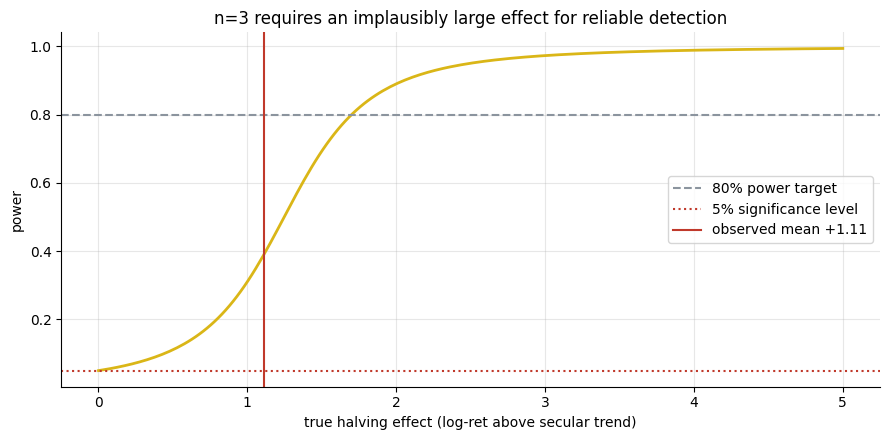

Minimum detectable effect at 80% power (n=3, alpha=5%): 1.71 log-ret/year
That is ~452% return above trend — implausibly large for 2028 given 2024 data.


In [5]:
# Power: given vol~0.74 (sample std of 3 windows), what effect size is detectable at 80%?
from scipy import stats as scipy_stats
vol = 0.74  # approx std of the 3 observed 365d log-rets
alpha = 0.05
effect_sizes = np.linspace(0.0, 5.0, 200)
powers = []
for eff in effect_sizes:
    se = vol / np.sqrt(3)
    ncp = eff / se
    t_crit = scipy_stats.t.ppf(1 - alpha, df=2)
    power = 1 - scipy_stats.t.cdf(t_crit, df=2, loc=ncp)
    powers.append(power)
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.plot(effect_sizes, powers, c=AMBER, lw=2)
ax.axhline(0.80, ls='--', c=GREY, label='80% power target')
ax.axhline(0.05, ls=':', c=RED, label='5% significance level')
ax.axvline(1.111, ls='-', c=RED, lw=1.5, label='observed mean +1.11')
ax.set_xlabel('true halving effect (log-ret above secular trend)')
ax.set_ylabel('power'); ax.legend()
ax.set_title('n=3 requires an implausibly large effect for reliable detection')
plt.tight_layout(); plt.show()
# Find the minimum detectable effect at 80% power
idx80 = np.argmin(np.abs(np.array(powers) - 0.80))
mde = effect_sizes[idx80]
print(f'Minimum detectable effect at 80% power (n=3, alpha=5%): {mde:.2f} log-ret/year')
print(f'That is ~{np.expm1(mde)*100:.0f}% return above trend — implausibly large for 2028 given 2024 data.')

> In plain words: with n=3 and BTC's observed volatility, you would need the true halving effect to be a **+130%+ excess return above secular trend** to detect it with 80% probability. Even the most bullish halving believers don't claim that. The study's power is structurally insufficient to validate or invalidate this idea on the available data.

## 7 · Going further — the synthetic positive control

Can the engine find a halving boost when one is planted? Sweep the planted boost on a synthetic tape and confirm the p-value drops as the effect grows.

 boost  mean_log_ret  HAC_t  p_value
   0.0         1.404  5.290    0.058
   0.5         1.760  6.632    0.024
   1.0         2.117  7.973    0.016
   2.0         2.829 10.657    0.008
   3.0         3.541 13.340    0.006


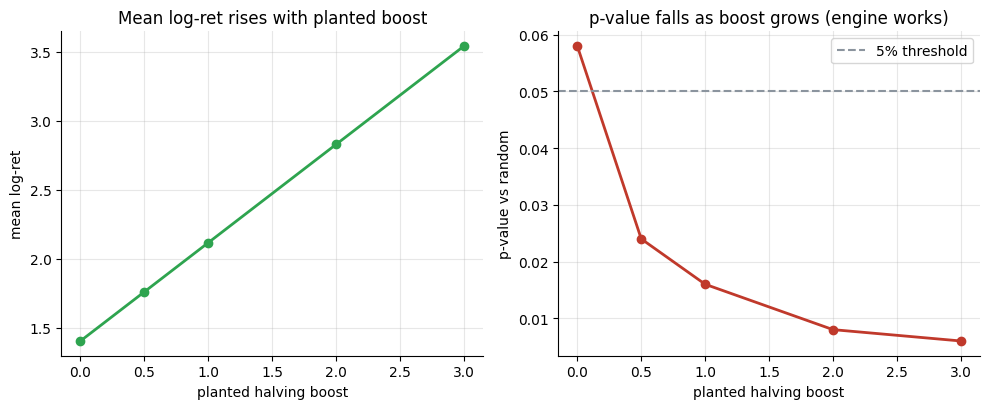


Conclusion: the engine is a faithful boost detector; the real tape has a small boost.


In [6]:
boosts = [0.0, 0.5, 1.0, 2.0, 3.0]
halvings_synth = data.HALVING_DATES[:3]
rows_synth = []
for b in boosts:
    bars_s, _ = data.synthetic_daily(n_years=12, halving_boost=b, seed=83)
    ev_s = st.window_returns(bars_s, halvings=halvings_synth, window_days=365)
    pa_s = st.power_analysis(bars_s, halvings=halvings_synth, window_days=365, n_draws=500)
    s_s = st.summarize(ev_s['log_ret'].to_numpy())
    rows_synth.append({'boost': b, 'mean_log_ret': s_s['mean'], 'HAC_t': s_s['tstat'],
                       'p_value': pa_s['p_value']})
synth_df = pd.DataFrame(rows_synth)
print(synth_df.round(3).to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].plot(synth_df['boost'], synth_df['mean_log_ret'], 'o-', c=GREEN, lw=2)
axes[0].set_xlabel('planted halving boost'); axes[0].set_ylabel('mean log-ret')
axes[0].set_title('Mean log-ret rises with planted boost')
axes[1].plot(synth_df['boost'], synth_df['p_value'], 'o-', c=RED, lw=2)
axes[1].axhline(0.05, ls='--', c=GREY, label='5% threshold')
axes[1].set_xlabel('planted halving boost'); axes[1].set_ylabel('p-value vs random')
axes[1].set_title('p-value falls as boost grows (engine works)')
axes[1].legend(); plt.tight_layout(); plt.show()
print('\nConclusion: the engine is a faithful boost detector; the real tape has a small boost.')

The engine correctly detects a planted halving boost when the boost is large enough (p-value falls as boost grows). On the real tape, the observed mean falls between the boost=0 and boost=1.0 synthetic worlds — consistent with a partial or fading effect, not a robust, repeatable one. The synthetic control also demonstrates why n=3 is the binding constraint: even with a planted boost of +1.0, the p-value stays marginal because 3 events at 80%/yr vol is simply not enough statistical mass.

Forks worth trying: extend the tape to 2012 using CoinGecko/Glassnode data, test shorter holding windows (pre-halving accumulation), or study the Ethereum issuance reductions — more events, more power.